Outlier detection and removal using Z Score Method

In [ ]:
#importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importing dataframe
df=pd.read_csv('placement.csv')

C:\Users\hp\AppData\Local\Temp\ipykernel_4524\2313712704.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\hp\AppData\Local\Temp\ipykernel_4524\2313712704.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


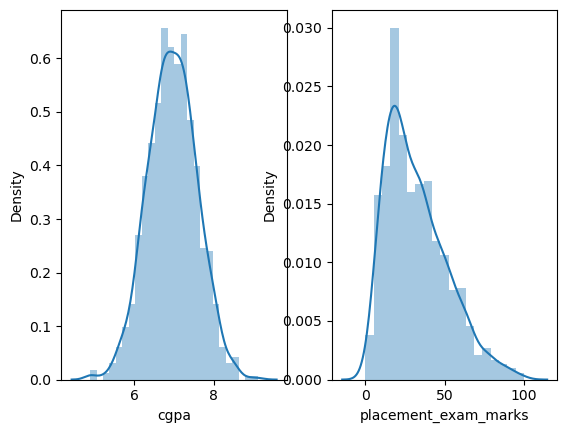

In [7]:
#Checking the distribution of the data:
plt.Figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

#it can be seen that the plot of cgpa is normally distributed but placement marks is not 
#hence we can apply the Z-Score method on cgpa column but not on marks column.

In [11]:
#calculations:
print('mean value of cgpa:',df['cgpa'].mean())
print('standard deviation of cgpa:',df['cgpa'].std())
print('maximum value of cgpa:',df['cgpa'].max())
print('minimum value of cgpa:',df['cgpa'].min())

cgpa_mean=df['cgpa'].mean()
cgpa_std=df['cgpa'].std()

mean value of cgpa: 6.96124
standard deviation of cgpa: 0.6158978751323894
maximum value of cgpa: 9.12
minimum value of cgpa: 4.89


In [13]:
#Finding the boundary values:
print('highest value allowed',cgpa_mean+3*cgpa_std)
print('lowest value allowed',cgpa_mean-3*cgpa_std)

max_all=cgpa_mean+3*cgpa_std
min_all=cgpa_mean-3*cgpa_std

highest value allowed 8.808933625397168
lowest value allowed 5.113546374602832


Finding Outliers

In [ ]:
outliers=df[(df['cgpa']>max_all)|(df['cgpa']<min_all)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


Handling Outliers: 

1. Trimming

In [18]:
trimmed_df=df[(df['cgpa']<max_all)&(df['cgpa']>min_all)]
trimmed_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


2. Capping

In [ ]:
df_capped=df.copy()
df_capped['cgpa']=np.where(
    df['cgpa']>max_all,
    max_all,
    np.where(
        df['cgpa']<min_all,
        min_all,
        df['cgpa']
    )
)

(1000, 3)